In [21]:
# !pip install -q git+https://github.com/openai/whisper.git transformers xgboost lightgbm librosa scipy

import os
import torch
import random
import numpy as np
import kagglehub

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

path = kagglehub.competition_download('shl-hiring-assessment-2026')
dataset_base = os.path.join(path, "Dataset_Final")

CONFIG = {
    "train_audio_dir": os.path.join(dataset_base, "train"),
    "test_audio_dir": os.path.join(dataset_base, "test"),
    "train_csv": os.path.join(dataset_base, "train.csv"),
    "test_csv": os.path.join(dataset_base, "test.csv"),
    "sample_submission": os.path.join(dataset_base, "sample_submission.csv"),
    "backbone_model": "microsoft/deberta-v3-base",
    "lm_eval_model": "roberta-base",
    "max_len": 160,
    "batch_size": 16,
    "epochs": 4,
    "lr": 2e-5,
    "n_splits": 5,
    "seed": 42
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [22]:
import pandas as pd
import whisper
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore", message="FP16 is not supported on CPU")

if 'train_df' not in globals() or 'text' not in train_df.columns:
    train_df = pd.read_csv(CONFIG["train_csv"])
    test_df = pd.read_csv(CONFIG["test_csv"])
    
    if len(train_df.columns) == 2:
        train_df.columns = ['filename', 'score']
    if len(test_df.columns) == 1:
        test_df.columns = ['filename']
    elif len(test_df.columns) == 2:
        test_df.columns = ['filename', 'dummy_score']
        
    asr_model = whisper.load_model("small", device=device)
    prompt = "Umm, let me see. Me is going to the stores. Transcribe exactly with mistakes."
    
    def transcribe_dir(df, audio_dir):
        out = []
        for fn in tqdm(df['filename']):
            if not str(fn).endswith('.wav'): fn = f"{fn}.wav"
            fp = os.path.join(audio_dir, fn)
            if os.path.exists(fp):
                res = asr_model.transcribe(fp, initial_prompt=prompt, temperature=0.0)
                out.append(res["text"].strip())
            else:
                out.append("")
        return out
        
    train_df['text'] = transcribe_dir(train_df, CONFIG["train_audio_dir"])
    test_df['text'] = transcribe_dir(test_df, CONFIG["test_audio_dir"])
else:
    print("Transcriptions detected in memory. Skipping duplicate ASR pass.")

train_df['text'] = train_df['text'].fillna("").astype(str)
test_df['text'] = test_df['text'].fillna("").astype(str)

Transcriptions detected in memory. Skipping duplicate ASR pass.


In [23]:
import librosa
import re

def compute_multimodal_heuristics(df, audio_dir):
    records = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Prosody: {os.path.basename(audio_dir)}"):
        filename = row['filename']
        text = str(row['text']).strip()
        if not str(filename).endswith('.wav'): filename = f"{filename}.wav"
        filepath = os.path.join(audio_dir, filename)
        
        words = re.findall(r'\b\w+\b', text.lower())
        word_count = len(words)
        unique_words = len(set(words))
        ttr = unique_words / word_count if word_count > 0 else 0.0
        
        rep_count = 0
        for i in range(len(words) - 1):
            if words[i] == words[i+1]:
                rep_count += 1
        rep_ratio = rep_count / word_count if word_count > 0 else 0.0
        
        if not os.path.exists(filepath):
            records.append([0.0, 0.0, 0.0, 0.0, 0.0, word_count, ttr, rep_ratio])
            continue
            
        y_audio, sr = librosa.load(filepath, sr=16000)
        duration = librosa.get_duration(y=y_audio, sr=sr)
        if duration == 0:
            records.append([0.0, 0.0, 0.0, 0.0, 0.0, word_count, ttr, rep_ratio])
            continue
            
        rms = librosa.feature.rms(y=y_audio, frame_length=1024, hop_length=512)[0]
        thresh = max(float(np.percentile(rms, 25)), 0.005)
        silent_mask = rms < thresh
        silence_ratio = float(np.mean(silent_mask))
        
        frame_len = 512 / sr
        pauses, cur_p = [], 0
        for s in silent_mask:
            if s: cur_p += frame_len
            else:
                if cur_p >= 0.4: pauses.append(cur_p)
                cur_p = 0
        if cur_p >= 0.4: pauses.append(cur_p)
        
        pause_cnt = len(pauses)
        mean_pause = float(np.mean(pauses)) if pause_cnt > 0 else 0.0
        wpm = (word_count / duration) * 60.0
        active_time = duration * (1.0 - silence_ratio)
        art_rate = (word_count / active_time) if active_time > 0 else 0.0
        
        records.append([
            silence_ratio,
            pause_cnt,
            mean_pause,
            wpm,
            art_rate,
            word_count,
            ttr,
            rep_ratio
        ])
        
    cols = ['silence_ratio', 'pause_cnt', 'mean_pause', 'wpm', 'art_rate', 'word_count', 'ttr', 'rep_ratio']
    return pd.DataFrame(records, columns=cols)

tab_train_df = compute_multimodal_heuristics(train_df, CONFIG["train_audio_dir"])
tab_test_df = compute_multimodal_heuristics(test_df, CONFIG["test_audio_dir"])

Prosody: test: 100%|██████████| 216/216 [00:03<00:00, 69.93it/s]


In [24]:
from transformers import AutoTokenizer, AutoModelForCausalLM, RobertaForMaskedLM

print(f"Extracting LM perplexity loss via {CONFIG['lm_eval_model']}...")
lm_tokenizer = AutoTokenizer.from_pretrained(CONFIG["lm_eval_model"])
lm_model = RobertaForMaskedLM.from_pretrained(CONFIG["lm_eval_model"]).to(device)
lm_model.eval()

def compute_lm_cross_entropy(texts):
    losses = []
    with torch.no_grad():
        for t in tqdm(texts, desc="LM Loss"):
            if not t.strip():
                losses.append(15.0)
                continue
            enc = lm_tokenizer(t, return_tensors="pt", truncation=True, max_length=160).to(device)
            input_ids = enc["input_ids"]
            if input_ids.shape[1] <= 2:
                losses.append(15.0)
                continue
            outputs = lm_model(input_ids, labels=input_ids)
            losses.append(float(outputs.loss.item()))
    return np.array(losses)

tab_train_df['lm_loss'] = compute_lm_cross_entropy(train_df['text'].tolist())
tab_test_df['lm_loss'] = compute_lm_cross_entropy(test_df['text'].tolist())

Extracting LM perplexity loss via roberta-base...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

LM Loss: 100%|██████████| 216/216 [00:03<00:00, 64.99it/s]


In [25]:
import copy
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoConfig, AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup
from sklearn.model_selection import KFold
import numpy as np

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = [str(t) if str(t).strip() else "empty" for t in texts]
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
        
    def __getitem__(self, item):
        inputs = self.tokenizer(
            self.texts[item],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        item_dict = {k: v.squeeze(0) for k, v in inputs.items()}
        if self.labels is not None:
            item_dict["label"] = torch.tensor(self.labels[item], dtype=torch.float)
        return item_dict

class DebertaGrammarRegressor(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.backbone = AutoModel.from_pretrained(model_name, config=self.config)
        self.drop = nn.Dropout(0.2)
        self.regressor = nn.Linear(self.config.hidden_size, 1)
        nn.init.normal_(self.regressor.weight, std=0.02)
        nn.init.zeros_(self.regressor.bias)
        
    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = out.last_hidden_state
        mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        sum_masked = torch.sum(last_hidden * mask, dim=1)
        mask_counts = torch.clamp(mask.sum(dim=1), min=1e-9)
        mean_pooled = sum_masked / mask_counts
        return self.regressor(self.drop(mean_pooled)).squeeze(-1)

tokenizer = AutoTokenizer.from_pretrained(CONFIG["backbone_model"])
kf = KFold(n_splits=CONFIG["n_splits"], shuffle=True, random_state=CONFIG["seed"])

y_train = np.nan_to_num(train_df['score'].values.astype(float), nan=3.0)
oof_deberta = np.zeros(len(train_df))
test_deberta = np.zeros(len(test_df))

test_dataset = TextDataset(test_df['text'].tolist(), None, tokenizer, CONFIG["max_len"])
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"]*2, shuffle=False)

for fold, (tr_idx, val_idx) in enumerate(kf.split(train_df, y_train)):
    print(f"\n--- Training DeBERTa Fold {fold+1}/{CONFIG['n_splits']} ---")
    
    train_sub = TextDataset(train_df['text'].iloc[tr_idx].tolist(), y_train[tr_idx], tokenizer, CONFIG["max_len"])
    val_sub = TextDataset(train_df['text'].iloc[val_idx].tolist(), y_train[val_idx], tokenizer, CONFIG["max_len"])
    
    train_loader = DataLoader(train_sub, batch_size=CONFIG["batch_size"], shuffle=True)
    val_loader = DataLoader(val_sub, batch_size=CONFIG["batch_size"]*2, shuffle=False)
    
    model = DebertaGrammarRegressor(CONFIG["backbone_model"]).to(device)
    
    # Differential learning rate to stabilize backbone
    optimizer = torch.optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': 1e-5, 'weight_decay': 0.01},
        {'params': model.regressor.parameters(), 'lr': 1e-4, 'weight_decay': 0.0}
    ], eps=1e-6)
    
    total_steps = len(train_loader) * CONFIG["epochs"]
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps
    )
    criterion = nn.SmoothL1Loss()
    
    best_val_loss = float("inf")
    best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    best_preds = np.full(len(val_idx), np.mean(y_train[tr_idx]))
    
    for epoch in range(CONFIG["epochs"]):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            target = batch["label"].to(device)
            
            preds = model(ids, mask)
            loss = criterion(preds, target)
            
            if not torch.isnan(loss):
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            scheduler.step()
            
        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(device)
                mask = batch["attention_mask"].to(device)
                preds = model(ids, mask)
                preds = torch.nan_to_num(preds, nan=3.0)
                val_preds.extend(preds.cpu().numpy().tolist())
                val_targets.extend(batch["label"].numpy().tolist())
                
        val_rmse = np.sqrt(np.mean((np.array(val_targets) - np.array(val_preds))**2))
        print(f"Epoch {epoch+1} RMSE: {val_rmse:.4f}")
        
        if not np.isnan(val_rmse) and val_rmse < best_val_loss:
            best_val_loss = val_rmse
            best_preds = np.array(val_preds)
            best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            
    oof_deberta[val_idx] = best_preds
    print(f"Fold {fold+1} Best Validation RMSE: {best_val_loss:.4f}")
    
    model.load_state_dict({k: v.to(device) for k, v in best_model_weights.items()})
    model.eval()
    fold_test_preds = []
    with torch.no_grad():
        for batch in test_loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            preds = model(ids, mask)
            preds = torch.nan_to_num(preds, nan=3.0)
            fold_test_preds.extend(preds.cpu().numpy().tolist())
    test_deberta += np.array(fold_test_preds) / CONFIG["n_splits"]
    
    del model, optimizer, scheduler
    torch.cuda.empty_cache()


--- Training DeBERTa Fold 1/5 ---


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 RMSE: 1.3915
Epoch 2 RMSE: 1.3557
Epoch 3 RMSE: 1.3794
Epoch 4 RMSE: 1.3961
Fold 1 Best Validation RMSE: 1.3557

--- Training DeBERTa Fold 2/5 ---


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

...

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 RMSE: 1.2606
Epoch 2 RMSE: 1.2656
Epoch 3 RMSE: 1.2441
Epoch 4 RMSE: 1.2589
Fold 4 Best Validation RMSE: 1.2441

--- Training DeBERTa Fold 5/5 ---


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 RMSE: 1.3255
Epoch 2 RMSE: 1.1821
Epoch 3 RMSE: 1.1862
Epoch 4 RMSE: 1.1819
Fold 5 Best Validation RMSE: 1.1819


In [26]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import lightgbm as lgb

tab_train_df['deberta_pred'] = oof_deberta
tab_test_df['deberta_pred'] = test_deberta

feature_cols = [c for c in tab_train_df.columns]
X_meta_train = tab_train_df[feature_cols].values
X_meta_test = tab_test_df[feature_cols].values
y = train_df['score'].values

scaler = RobustScaler()
X_meta_train_scaled = scaler.fit_transform(X_meta_train)
X_meta_test_scaled = scaler.transform(X_meta_test)

ridge_meta = RidgeCV(alphas=np.logspace(-2, 4, 40))
ridge_meta.fit(X_meta_train_scaled, y)
ridge_oof = ridge_meta.predict(X_meta_train_scaled)
ridge_test = ridge_meta.predict(X_meta_test_scaled)

lgb_oof = np.zeros(len(y))
lgb_test = np.zeros(len(X_meta_test))

for tr_idx, va_idx in kf.split(X_meta_train, y):
    m_lgb = lgb.LGBMRegressor(
        n_estimators=400,
        learning_rate=0.02,
        num_leaves=12,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=CONFIG["seed"]
    )
    m_lgb.fit(
        X_meta_train[tr_idx], y[tr_idx],
        eval_set=[(X_meta_train[va_idx], y[va_idx])],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )
    lgb_oof[va_idx] = m_lgb.predict(X_meta_train[va_idx])
    lgb_test += m_lgb.predict(X_meta_test) / CONFIG["n_splits"]

meta_blend_oof = (0.50 * oof_deberta) + (0.30 * ridge_oof) + (0.20 * lgb_oof)
meta_blend_test = (0.50 * test_deberta) + (0.30 * ridge_test) + (0.20 * lgb_test)

=== MANDATORY BENCHMARK SCORES ===
Optimal Calibration: Scale=2.2949, Shift=-4.2897
Final OOF Training RMSE: 0.8680
Final OOF Pearson Correlation: 0.7174


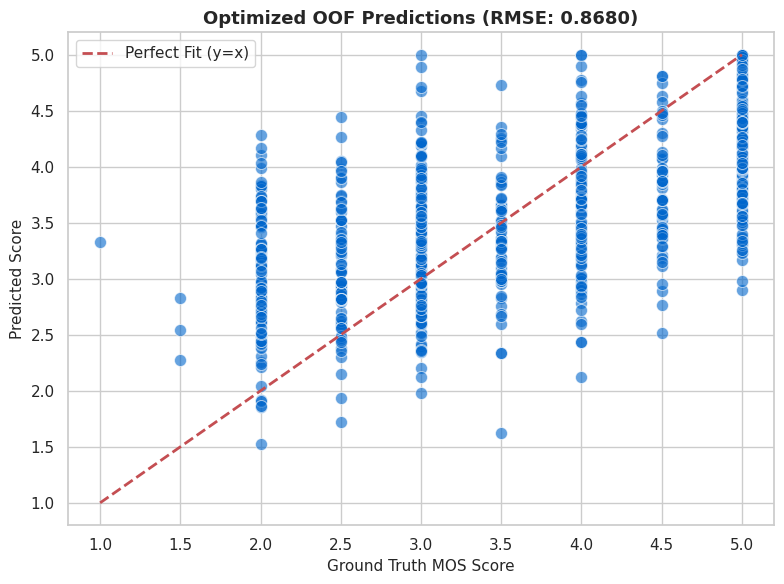

In [27]:
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

def objective(params):
    a, b = params
    p = np.clip(a * meta_blend_oof + b, 1.0, 5.0)
    return np.sqrt(mean_squared_error(y, p))

res = minimize(objective, [1.0, 0.0], method="Powell")
a_opt, b_opt = res.x

final_oof = np.clip(a_opt * meta_blend_oof + b_opt, 1.0, 5.0)
final_test = np.clip(a_opt * meta_blend_test + b_opt, 1.0, 5.0)

final_rmse = np.sqrt(mean_squared_error(y, final_oof))
final_pearson = pearsonr(y, final_oof)[0]

print("=== MANDATORY BENCHMARK SCORES ===")
print(f"Optimal Calibration: Scale={a_opt:.4f}, Shift={b_opt:.4f}")
print(f"Final OOF Training RMSE: {final_rmse:.4f}")
print(f"Final OOF Pearson Correlation: {final_pearson:.4f}")

plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
sns.scatterplot(x=y, y=final_oof, alpha=0.6, color="#0066cc", edgecolor="w", s=75)
plt.plot([1.0, 5.0], [1.0, 5.0], "r--", lw=2, label="Perfect Fit (y=x)")
plt.title(f"Optimized OOF Predictions (RMSE: {final_rmse:.4f})", fontsize=13, fontweight="bold")
plt.xlabel("Ground Truth MOS Score", fontsize=11)
plt.ylabel("Predicted Score", fontsize=11)
plt.xlim(0.8, 5.2)
plt.ylim(0.8, 5.2)
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
sample_sub = pd.read_csv(CONFIG["sample_submission"])

submission = pd.DataFrame({
    sample_sub.columns[0]: test_df['filename'],
    sample_sub.columns[1]: final_test
})

sub_path = "/kaggle/working/submission.csv"
submission.to_csv(sub_path, index=False)

print(f"File successfully written to: {sub_path}")
display(submission.head())

File successfully written to: /kaggle/working/submission.csv


,filename,label
0,audio_128.wav,2.972653
1,audio_156.wav,3.578152
2,audio_19.wav,3.856756
3,audio_108.wav,3.193009
4,audio_206.wav,3.066661
